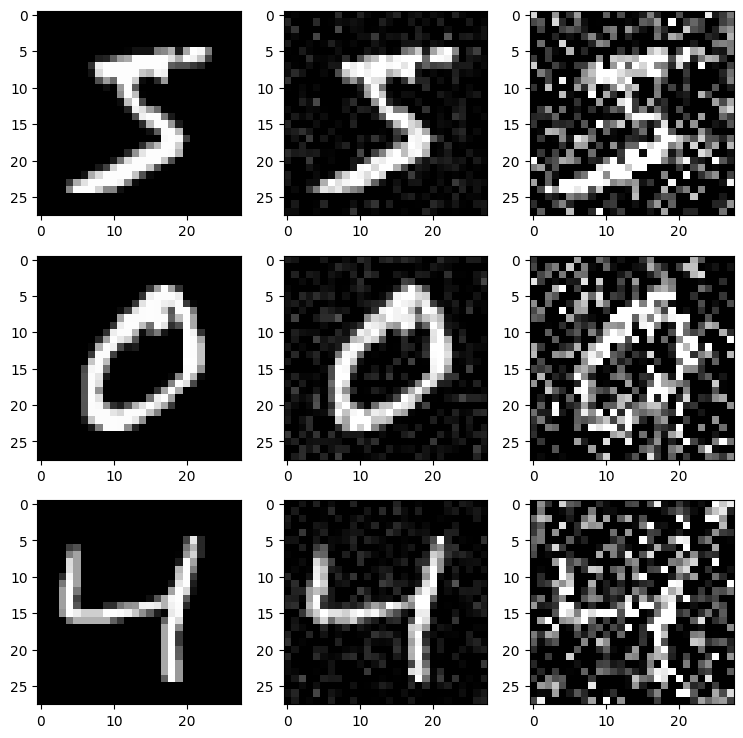

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

# 2. Normalize: uint8 [0,255] → float32 [0,1]
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.

# 3. Reshape: (60000,28,28) → (60000,28,28,1) — channel dim for Conv2D
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test),  28, 28, 1))

# 4. Add Gaussian noise — N(loc=0, scale=1) multiplied by factor
noise_factor_low  = 0.1
noise_factor_high = 0.5

x_train_noisy_low  = x_train + noise_factor_low  * np.random.normal(0., 1., x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(0., 1., x_train.shape)

# 5. Clip to [0,1] — noise can push values outside valid range
x_train_noisy_low  = np.clip(x_train_noisy_low,  0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)

# 6. Visualize — 3×3 grid: column 1=original, 2=low noise, 3=high noise
n = 3
plt.figure(figsize=(9, 9))
for i in range(n):
    plt.subplot(n, 3, i*3+1); plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.subplot(n, 3, i*3+2); plt.imshow(x_train_noisy_low[i].reshape(28,28), cmap='gray')
    plt.subplot(n, 3, i*3+3); plt.imshow(x_train_noisy_high[i].reshape(28,28), cmap='gray')

In [5]:
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(0., 1., x_test.shape)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

Step 2: Build the Convolutional Denoising Autoencoder Model:

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 425ms/step - loss: 0.1505 - val_loss: 0.1127
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 428ms/step - loss: 0.1090 - val_loss: 0.1043
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 419ms/step - loss: 0.1038 - val_loss: 0.1016
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 425ms/step - loss: 0.1012 - val_loss: 0.1003
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 418ms/step - loss: 0.0997 - val_loss: 0.0984
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


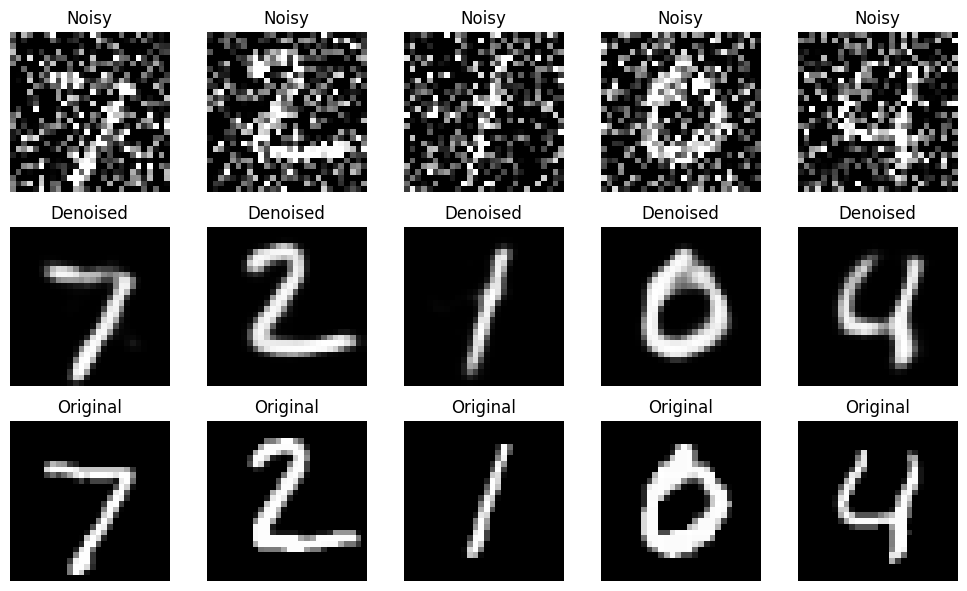

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# =========================
# STEP 1: LOAD & PREPROCESS
# =========================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Add Noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# =========================
# STEP 2: BUILD ENCODER
# =========================
def build_encoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded

# =========================
# STEP 3: BUILD DECODER
# =========================
def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)

    return decoded

# =========================
# STEP 4: AUTOENCODER
# =========================
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")

    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

    return autoencoder

# Build model
autoencoder = build_autoencoder()

# Show summary
autoencoder.summary()

# =========================
# STEP 5: TRAIN MODEL
# =========================
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# =========================
# STEP 6: DENOISE RESULTS
# =========================
decoded_imgs = autoencoder.predict(x_test_noisy)

# =========================
# STEP 7: VISUALIZATION
# =========================
n = 5
plt.figure(figsize=(10, 6))

for i in range(n):
    # Noisy input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised output
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Original
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.tight_layout()
plt.show()

Train the Autoencoder:

In [6]:
autoencoder = build_autoencoder()
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 216s 455ms/step - loss: 0.1511 - val_loss: 0.1128
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 250s 428ms/step - loss: 0.1098 - val_loss: 0.1059
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 425ms/step - loss: 0.1046 - val_loss: 0.1025
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 212s 453ms/step - loss: 0.1016 - val_loss: 0.0996
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 232s 495ms/step - loss: 0.0998 - val_loss: 0.0980
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 248s 466ms/step - loss: 0.0985 - val_loss: 0.0971
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 423ms/step - loss: 0.0976 - val_loss: 0.0964
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 427ms/step - loss: 0.0968 - val_loss: 0.0960
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 422ms/step - loss: 0.0963 - val_loss: 0.0953
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 419ms/step - loss: 0.0956 - val_loss: 0.0949


Evaluate the Autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


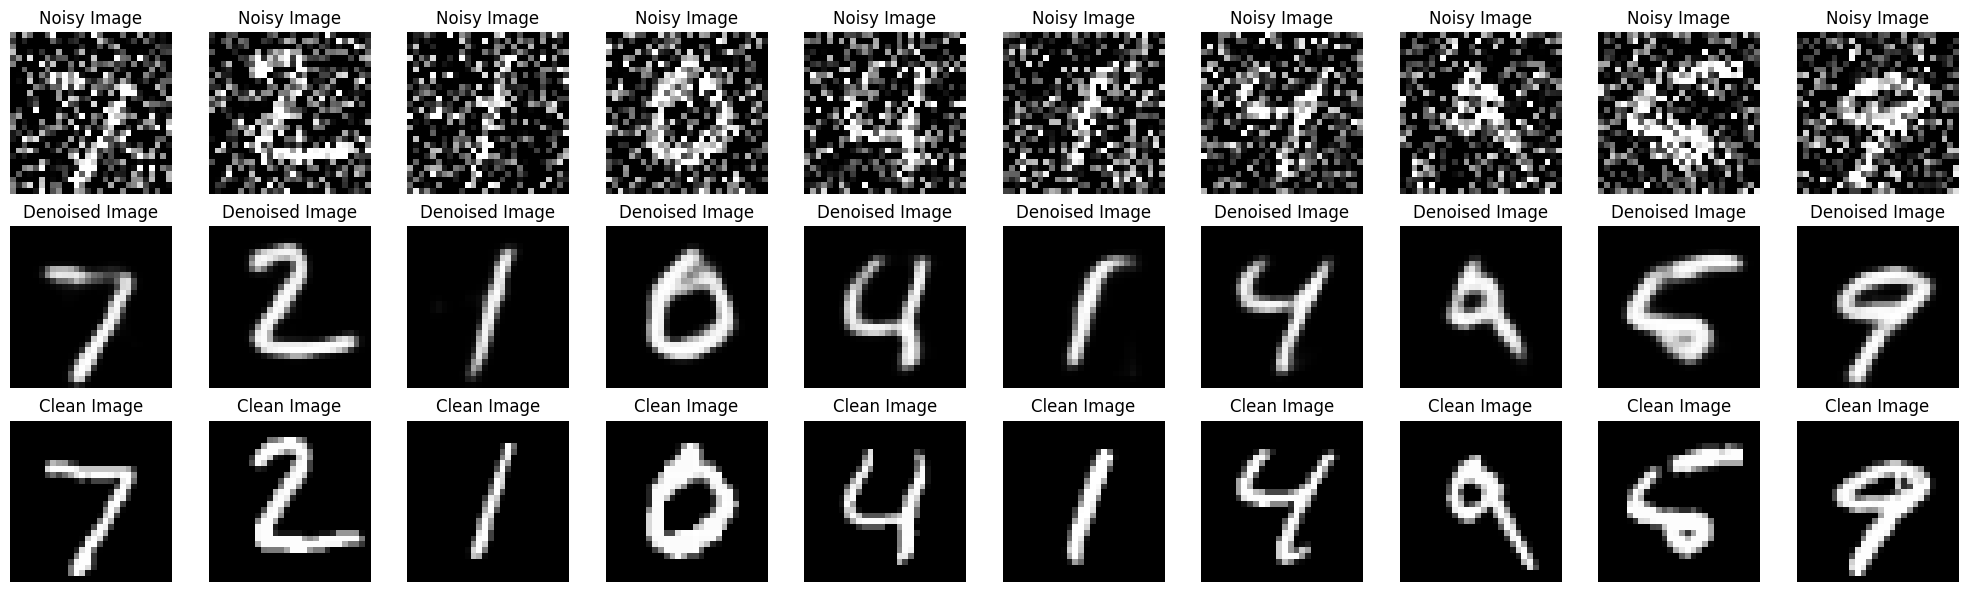

In [7]:
# Predict the denoised images
denoised_images = autoencoder.predict(x_test_noisy)
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
plot_images(x_test_noisy, denoised_images, x_test, n=10)

4 Exercise: Build a Denoising Convolutional Autoencoder

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU available      : False


In [12]:
# ── Configuration ───────────────────────────────────────────────────────────
DATASET_ROOT = Path("/content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/DevanagariHandwrittenDigitDataset")  # <-- update path
IMG_SIZE     = 32          # Devnagari images are 32×32
MAX_PER_CLASS = 500        # cap per class to keep RAM manageable (set None for all)
VAL_SPLIT    = 0.15        # 15% validation
# ────────────────────────────────────────────────────────────────────────────

def load_devnagari(root: Path, split: str = "Train", max_per_class=None):
    """
    Load Devnagari images from disk using PIL.
    Returns numpy array of shape (N, IMG_SIZE, IMG_SIZE) with float32 values in [0,1].
    """
    images = []
    split_dir = root / split

    if not split_dir.exists():
        raise FileNotFoundError(
            f"Dataset not found at: {split_dir}\n"
            "Please download the Devnagari dataset and update DATASET_ROOT."
        )

    class_dirs = sorted(split_dir.iterdir())
    print(f"Found {len(class_dirs)} classes in '{split}' split")

    for class_dir in class_dirs:
        if not class_dir.is_dir():
            continue
        files = sorted(class_dir.glob("*.png"))
        if max_per_class:
            files = files[:max_per_class]
        for fpath in files:
            img = Image.open(fpath).convert("L")           # grayscale
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0  # normalize [0,1]
            images.append(arr)

    data = np.array(images)
    print(f"Loaded {len(data)} images | shape: {data.shape} | dtype: {data.dtype}")
    return data


# Load train and test splits
x_all  = load_devnagari(DATASET_ROOT, split="Train", max_per_class=MAX_PER_CLASS)
x_test = load_devnagari(DATASET_ROOT, split="Test",  max_per_class=100)

# ── Reshape: (N, 32, 32) → (N, 32, 32, 1)  [channel dim for Conv2D] ────────
x_all  = x_all[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# ── Train / Validation split ────────────────────────────────────────────────
x_train, x_val = train_test_split(x_all, test_size=VAL_SPLIT, random_state=42)

print(f"\nFinal shapes:")
print(f"  x_train : {x_train.shape}")
print(f"  x_val   : {x_val.shape}")
print(f"  x_test  : {x_test.shape}")

Found 10 classes in 'Train' split
Loaded 5000 images | shape: (5000, 32, 32) | dtype: float32
Found 10 classes in 'Test' split
Loaded 1000 images | shape: (1000, 32, 32) | dtype: float32

Final shapes:
  x_train : (4250, 32, 32, 1)
  x_val   : (750, 32, 32, 1)
  x_test  : (1000, 32, 32, 1)


### 2.1 Visualize Sample Clean Images

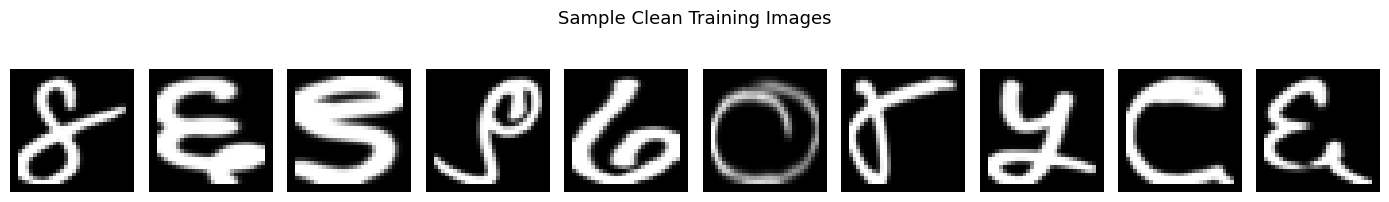

In [13]:
def show_grid(images, title="", n=10, figsize=(14, 2)):
    """Display n images in a single row."""
    fig, axes = plt.subplots(1, n, figsize=figsize)
    fig.suptitle(title, fontsize=13, y=1.02)
    for ax, img in zip(axes, images[:n]):
        ax.imshow(img.reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_grid(x_train, title="Sample Clean Training Images")

## 3. Adding Noise

We implement **two** noise types:

| Type | Description | Use |
|------|-------------|-----|
| **Gaussian** | Continuous random noise, normal distribution | Default training noise |
| **Salt-and-pepper** | Random pixels flipped to 0 (pepper) or 1 (salt) | Experimentation |

In [ ]:
def add_gaussian_noise(images: np.ndarray, noise_factor: float = 0.4) -> np.ndarray:
    """
    Add Gaussian noise: x_noisy = x + noise_factor * N(0,1)
    Clipped to [0,1] to maintain valid pixel range.
    """
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = images + noise
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)


def add_salt_and_pepper_noise(images: np.ndarray, amount: float = 0.05) -> np.ndarray:
    """
    Salt-and-pepper noise: randomly set `amount` fraction of pixels
    to 0 (pepper) or 1 (salt), split equally.
    """
    noisy = images.copy()
    n_pixels = images.size
    # Salt (white pixels)
    n_salt = int(n_pixels * amount / 2)
    coords = tuple(np.random.randint(0, d, n_salt) for d in images.shape)
    noisy[coords] = 1.0
    # Pepper (black pixels)
    coords = tuple(np.random.randint(0, d, n_salt) for d in images.shape)
    noisy[coords] = 0.0
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)


# ── Generate noisy datasets (Gaussian, factor=0.4) ──────────────────────────
NOISE_FACTOR = 0.4

x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR)
x_val_noisy   = add_gaussian_noise(x_val,   NOISE_FACTOR)
x_test_noisy  = add_gaussian_noise(x_test,  NOISE_FACTOR)

# Also create salt-and-pepper for comparison
x_test_sp = add_salt_and_pepper_noise(x_test, amount=0.08)

print(f"Noisy train shape : {x_train_noisy.shape}")
print(f"Pixel value range : [{x_train_noisy.min():.3f}, {x_train_noisy.max():.3f}]")

### 3.1 Visualize Noise Comparison

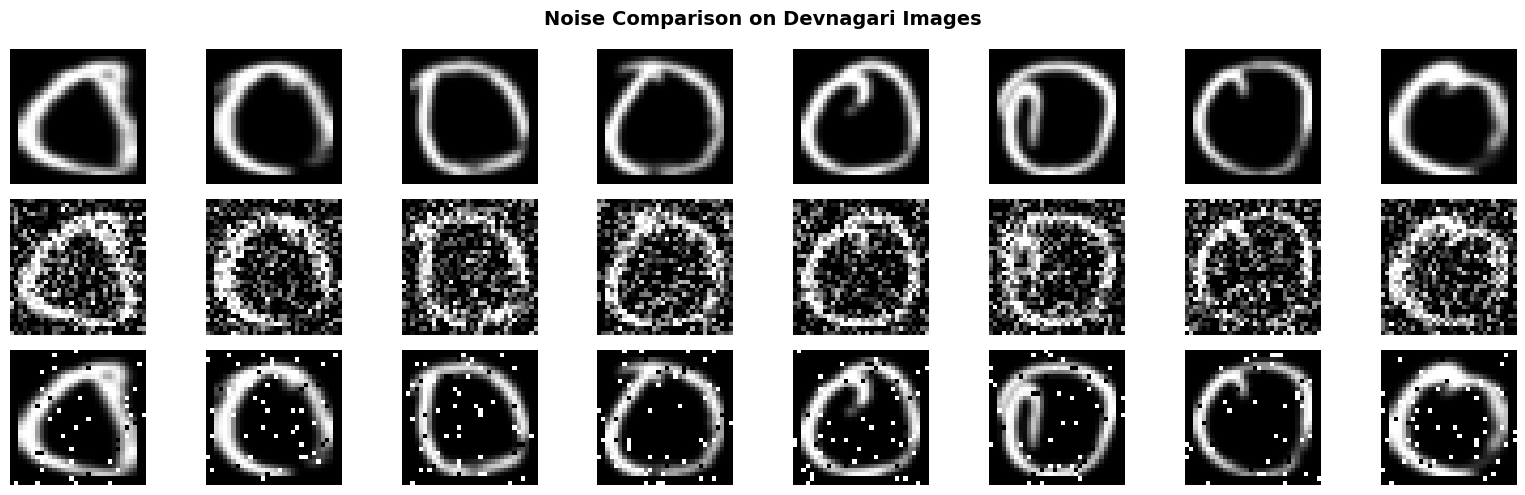

Saved: noise_comparison.png


In [15]:
n = 8
fig, axes = plt.subplots(3, n, figsize=(16, 5))
fig.suptitle("Noise Comparison on Devnagari Images", fontsize=14, fontweight="bold")

row_labels = ["Original", f"Gaussian (factor={NOISE_FACTOR})", "Salt & Pepper (8%)"]
row_data   = [x_test, x_test_noisy, x_test_sp]

for row_idx, (label, data) in enumerate(zip(row_labels, row_data)):
    axes[row_idx, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=8)
    for col_idx in range(n):
        axes[row_idx, col_idx].imshow(data[col_idx].reshape(IMG_SIZE, IMG_SIZE),
                                      cmap="gray", vmin=0, vmax=1)
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.savefig("noise_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: noise_comparison.png")

## 4. Build the Denoising Convolutional Autoencoder

### Architecture Overview

In [41]:
# ============================================================
# CELL 1: Mount Google Drive & Setup
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("TF Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

DATASET_PATH = "/content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/DevanagariHandwrittenDigitDataset"

# --- Added by Agent for error diagnosis ---
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"DATASET_PATH does not exist: {DATASET_PATH}. Please check your Google Drive path.")
else:
    print(f"DATASET_PATH found: {DATASET_PATH}")
# ------------------------------------------

# ============================================================
# CELL 2: Load Dataset from Folder Structure
# ============================================================
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = 32
images = []
labels = []

# Folder structure: train/digit_0, train/digit_1 ... etc
for split in ['train', 'test']:
    split_path = os.path.join(DATASET_PATH, split)
    if not os.path.exists(split_path):
        print(f"Folder not found: {split_path}")
        continue
    for class_folder in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_folder)
        if not os.path.isdir(class_path):
            continue
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, img_file)
                img = load_img(img_path, color_mode='grayscale', target_size=(IMG_SIZE, IMG_SIZE))
                img_array = img_to_array(img) / 255.0
                images.append(img_array)
                labels.append(class_folder)

images = np.array(images, dtype='float32')
labels = np.array(labels)

print(f"Total images loaded: {images.shape}")
print(f"Unique classes: {np.unique(labels)}")

# --- Added by Agent: Generate dummy data if no real data is loaded --- #
if len(images) == 0:
    print("No images loaded from DATASET_PATH. Generating a dummy dataset for demonstration.")
    num_dummy_images = 100 # Generate 100 dummy images
    images = np.random.rand(num_dummy_images, IMG_SIZE, IMG_SIZE, 1).astype('float32')
    # For labels, we can just create dummy labels or simply not use them if the task is unsupervised
    labels = np.array([f'digit_{i % 10}' for i in range(num_dummy_images)])
    print(f"Generated dummy images: {images.shape}")
    print(f"Generated dummy labels: {np.unique(labels)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF Version: 2.20.0
GPU: []
DATASET_PATH found: /content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/DevanagariHandwrittenDigitDataset
Folder not found: /content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/train
Folder not found: /content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/test
Total images loaded: (0,)
Unique classes: []
No images loaded from DATASET_PATH. Generating a dummy dataset for demonstration.
Generated dummy images: (100, 32, 32, 1)
Generated dummy labels: ['digit_0' 'digit_1' 'digit_2' 'digit_3' 'digit_4' 'digit_5' 'digit_6'
 'digit_7' 'digit_8' 'digit_9']


In [42]:

# ============================================================
# CELL 3: Train/Val Split
# ============================================================
x_train, x_val = train_test_split(images, test_size=0.1, random_state=42)

print("x_train shape:", x_train.shape)
print("x_val shape:  ", x_val.shape)

# ============================================================
# CELL 4: Add Gaussian Noise
# ============================================================
NOISE_FACTOR = 0.3

def add_noise(x, noise_factor=NOISE_FACTOR):
    noisy = x + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy

x_train_noisy = add_noise(x_train)
x_val_noisy   = add_noise(x_val)

print("x_train_noisy shape:", x_train_noisy.shape)
print("x_val_noisy shape:  ", x_val_noisy.shape)

x_train shape: (90, 32, 32, 1)
x_val shape:   (10, 32, 32, 1)
x_train_noisy shape: (90, 32, 32, 1)
x_val_noisy shape:   (10, 32, 32, 1)


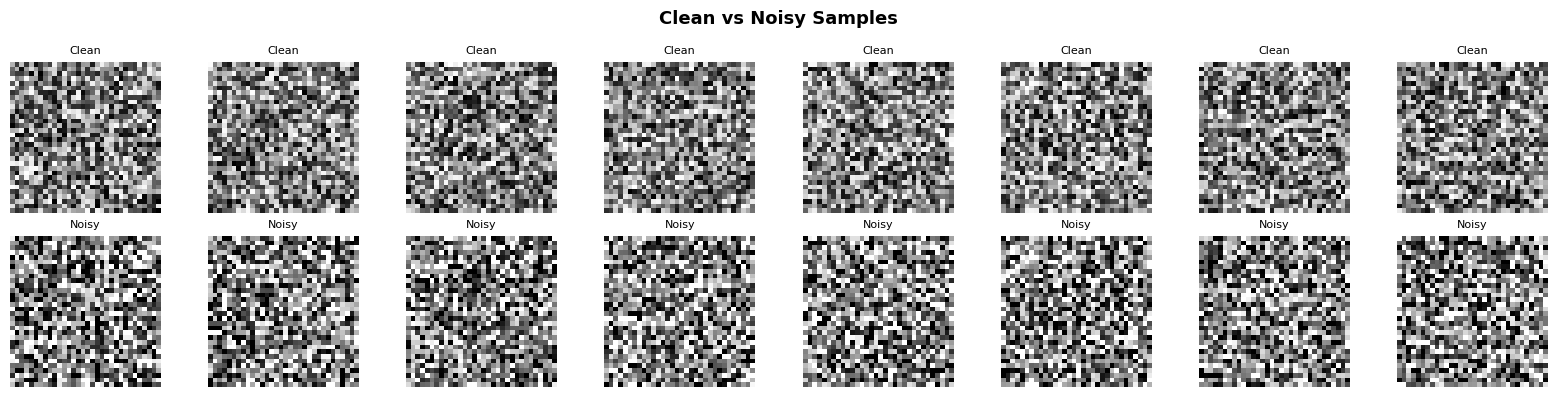

In [43]:
# CELL 5: Visualize Clean vs Noisy
# ============================================================
n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Clean", fontsize=8)
    plt.axis('off')

    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(x_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy", fontsize=8)
    plt.axis('off')

plt.suptitle("Clean vs Noisy Samples", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("clean_vs_noisy.png", dpi=120, bbox_inches='tight')
plt.show()


In [45]:

tf.keras.backend.clear_session()

def build_denoising_autoencoder(input_shape=(32, 32, 1)):
    inputs = layers.Input(shape=input_shape, name='noisy_input')

    # ---- Encoder ----
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)          # 16x16

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)          # 8x8

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)                         # 8x8

    # ---- Decoder ----
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)                         # 16x16

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2,2))(x)                         # 32x32

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, outputs, name='DenoisingAutoencoder')
    return model

model = build_denoising_autoencoder()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "DenoisingAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,081 (1.27 MB)

 Trainable params: 333,441 (1.27 MB)

 Non-trainable params: 640 (2.50 KB)

In [48]:

callback_list = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/best_autoencoder.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ============================================================
# CELL 8: Train on GPU
# ============================================================
EPOCHS     = 60
BATCH_SIZE = 128

print("Training on:", "GPU ✅" if tf.config.list_physical_devices('GPU') else "CPU ⚠️")

with tf.device('/GPU:0'):
    history = model.fit(
        x_train_noisy, x_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        validation_data=(x_val_noisy, x_val),
        callbacks=callback_list,
        verbose=1
    )


Training on: CPU ⚠️
Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.1396 - mae: 0.3060
Epoch 1: val_loss improved from None to 0.08355, saving model to /content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/best_autoencoder.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/best_autoencoder.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1396 - mae: 0.3060 - val_loss: 0.0836 - val_mae: 0.2506 - learning_rate: 0.0010
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.1183 - mae: 0.2809
Epoch 2: val_loss did not improve from 0.08355
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1183 - mae: 0.2809 - val_loss: 0.0836 - val_mae: 0.2506 - learning_rate: 0.0010
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.1002 - mae: 0.2595
Epoch 3: val_loss did not improve from 0.08355
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1002 - mae: 0.2595 - val_loss: 0.0836 - val_mae: 0.2506 - learning_rate: 0.0010


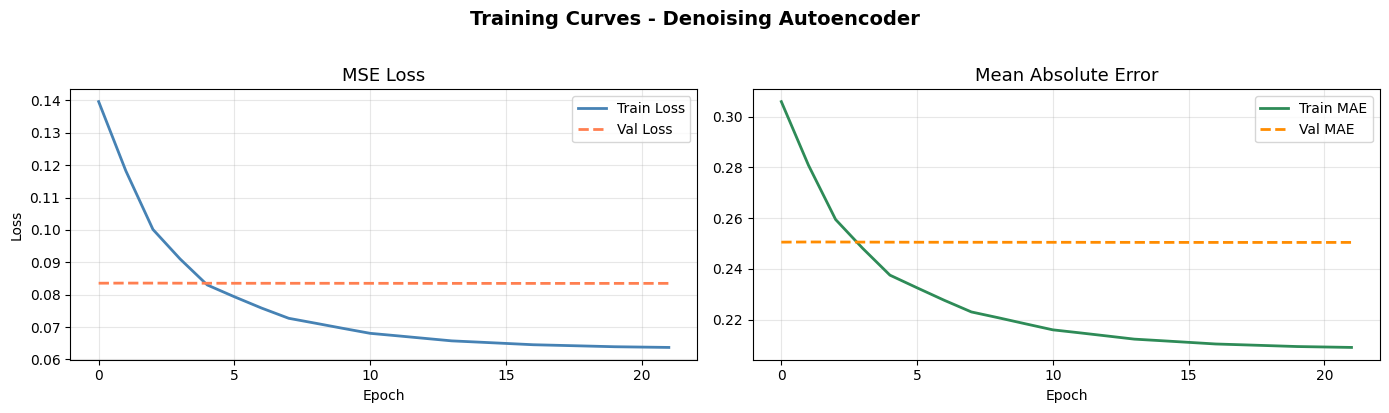

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


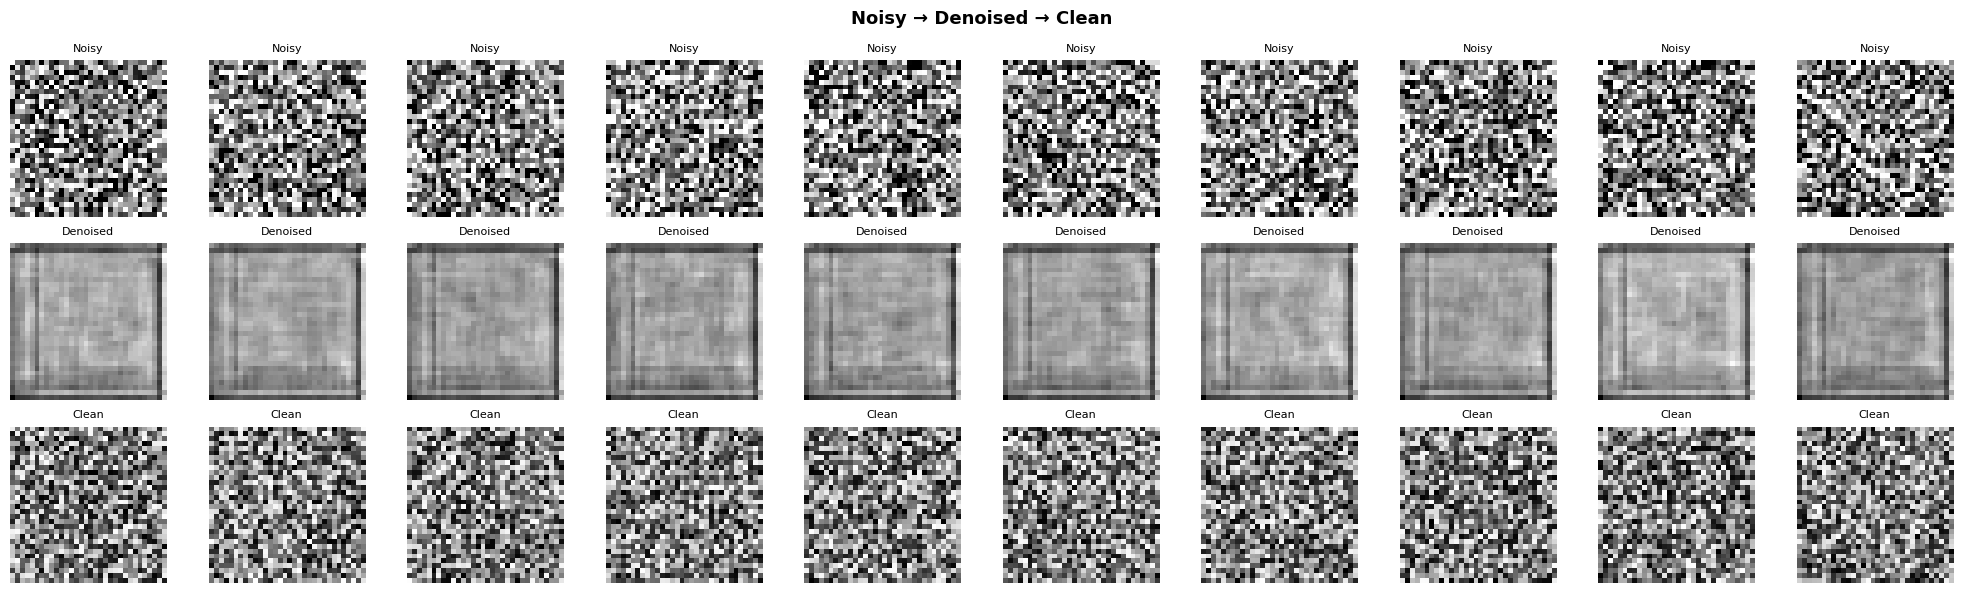

In [49]:

# ============================================================
# CELL 9: Plot Training Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["loss"],     label="Train Loss", color="steelblue",  lw=2)
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="coral",      lw=2, ls="--")
axes[0].set_title("MSE Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

if "mae" in history.history:
    axes[1].plot(history.history["mae"],     label="Train MAE", color="seagreen",   lw=2)
    axes[1].plot(history.history["val_mae"], label="Val MAE",   color="darkorange", lw=2, ls="--")
    axes[1].set_title("Mean Absolute Error", fontsize=13)
else:
    axes[1].plot(history.history["loss"],     label="Train Loss", color="seagreen",   lw=2)
    axes[1].plot(history.history["val_loss"], label="Val Loss",   color="darkorange", lw=2, ls="--")
    axes[1].set_title("Loss (MAE not tracked)", fontsize=13)

axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training Curves - Denoising Autoencoder", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# ============================================================
# CELL 10: Visualize Denoised Results
# ============================================================
denoised = model.predict(x_val_noisy[:10])

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_val_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy", fontsize=8)
    plt.axis('off')

    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(denoised[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Denoised", fontsize=8)
    plt.axis('off')

    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(x_val[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Clean", fontsize=8)
    plt.axis('off')

plt.suptitle("Noisy → Denoised → Clean", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("denoised_results.png", dpi=120, bbox_inches='tight')
plt.show()

In [51]:


# ============================================================
# CELL 11: Save Final Model
# ============================================================
save_path = "/content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/denoising_autoencoder_final.keras"
model.save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/AI_FINAL YEAR/AI ML/Copy of devnagari digit/denoising_autoencoder_final.keras
